# 实验十三：西游记文本爬取与词云分析

## 实验目标

参考《Python中文自然语言处理》教材第二章内容，完成以下任务：

1. 使用 `requests` 和 `BeautifulSoup` 从在线语料网页爬取《西游记》全文内容
2. 对爬取的语料进行预处理（清洗、分词、去停用词）
3. 统计词频并可视化高频词
4. 生成词云图

## 技术栈

| 环节 | 工具/库 | 说明 |
|------|---------|------|
| 爬虫 | requests + BeautifulSoup | 多段重试下载 + 书目页信息提取 |
| 分词 | jieba | 精确模式中文分词 |
| 停用词 | 中文停用词表 | 过滤无意义虚词 |
| 词频统计 | collections.Counter | 统计词频 |
| 可视化 | matplotlib + wordcloud | 柱状图 + 词云图 |

## 数据来源

古腾堡计划 (Project Gutenberg) —《西游记》原文 (ID: 23962)，UTF-8 纯文本格式

## 1. 导入库

In [90]:
import requests
from bs4 import BeautifulSoup
import jieba
import re
import os
import time
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib
from wordcloud import WordCloud

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'KaiTi']
matplotlib.rcParams['axes.unicode_minus'] = False

print('所有库导入成功！')
print(f'jieba 版本: {jieba.__version__}')

所有库导入成功！
jieba 版本: 0.42.1


## 2. 爬取西游记全文

### 2.1 爬虫策略

从 Gutenberg 获取《西游记》全文。由于国内网络环境可能导致大文件传输中断，采用**多段重试下载**策略：

1. 通过 HTTP `Range` 请求头分段下载，每段 300KB
2. 下载失败自动重试下一段
3. 拼接所有成功下载的段落
4. 成功后缓存到本地 `xiyouji_full.txt`，下次直接读取

同时用 `requests` + `BeautifulSoup` 爬取 Gutenberg 书目页，获取书名、作者等元数据。

In [91]:
# 2.1.1 多段重试下载 Gutenberg 西游记全文

save_path = 'xiyouji_full.txt'
gutenberg_url = 'https://www.gutenberg.org/cache/epub/23962/pg23962.txt'
all_text = ''

# 如果本地已有缓存，优先使用
if os.path.exists(save_path) and os.path.getsize(save_path) > 500000:
    print(f'发现本地缓存: {save_path} ({os.path.getsize(save_path) / 1024:.1f} KB)')
    with open(save_path, 'r', encoding='utf-8') as f:
        all_text = f.read()
    print(f'已加载 {len(all_text):,} 字符')
else:
    print(f'正在从 Gutenberg 下载...')
    session = requests.Session()
    session.headers.update({
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
        'Accept': '*/*',
    })

    max_attempts = 8
    downloaded_chunks = {}

    for attempt in range(max_attempts):
        chunk_size = 300000
        start_byte = len(downloaded_chunks) * chunk_size
        end_byte = start_byte + chunk_size - 1

        try:
            headers = {'Range': f'bytes={start_byte}-{end_byte}'}
            r = session.get(gutenberg_url, headers=headers, timeout=60)
            if r.status_code in [200, 206]:
                data = r.content
                if data:
                    downloaded_chunks[attempt] = data
                    print(f'  段 {attempt+1}: {start_byte:,}-{end_byte:,} 获取 {len(data):,} bytes (HTTP {r.status_code})')
                if r.status_code == 200 or len(data) < chunk_size:
                    break
            else:
                print(f'  段 {attempt+1}: HTTP {r.status_code}')
                break
        except Exception as e:
            print(f'  段 {attempt+1}: {type(e).__name__}')
            time.sleep(1)

    total_bytes = sum(len(c) for c in downloaded_chunks.values())
    if total_bytes > 50000:
        sorted_chunks = [downloaded_chunks[i] for i in sorted(downloaded_chunks.keys())]
        all_text = b''.join(sorted_chunks).decode('utf-8', errors='replace')
        print(f'下载完成: {total_bytes:,} bytes -> {len(all_text):,} 字符')

        with open(save_path, 'w', encoding='utf-8') as f:
            f.write(all_text)
        print(f'已保存到 {save_path}')
    else:
        print(f'下载数据不足 ({total_bytes} bytes)，请检查网络')

正在从 Gutenberg 下载...
  段 1: 0-299,999 获取 300,000 bytes (HTTP 206)
  段 2: ChunkedEncodingError
  段 3: 300,000-599,999 获取 300,000 bytes (HTTP 206)
  段 4: ChunkedEncodingError
  段 5: ChunkedEncodingError
  段 6: ChunkedEncodingError
  段 7: ChunkedEncodingError
  段 8: ChunkedEncodingError
下载完成: 600,000 bytes -> 210,521 字符
已保存到 xiyouji_full.txt


In [92]:
# 2.1.2 使用 requests + BeautifulSoup 爬取 Gutenberg 书目页
# 获取《西游记》的元数据（书名、作者、语种等）

catalog_url = 'https://www.gutenberg.org/ebooks/23962'

try:
    resp = requests.get(catalog_url, timeout=20, headers={
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
    })
    resp.encoding = 'utf-8'
    print(f'书目页状态码: {resp.status_code}')

    if resp.status_code == 200:
        soup = BeautifulSoup(resp.text, 'html.parser')

        print('\n===== 书目信息 =====')
        title_tag = soup.find('h1')
        if title_tag:
            print(f'标题: {title_tag.get_text(strip=True)}')

        table = soup.find('table', class_='bibrec')
        if table:
            for row in table.find_all('tr'):
                th = row.find('th')
                td = row.find('td')
                if th and td:
                    print(f'{th.get_text(strip=True)}: {td.get_text(strip=True)}')

        all_links = soup.find_all('a')
        print(f'\n页面共包含 {len(all_links)} 个链接')
        print('\nBeautifulSoup 爬虫演示完成！')
    else:
        print(f'无法访问书目页 (HTTP {resp.status_code})')
except Exception as e:
    print(f'爬取书目页失败: {type(e).__name__}: {e}')
    print('（这不影响正文分析，正文已通过多段下载获取）')

书目页状态码: 200

===== 书目信息 =====
标题: 西遊記 by Cheng'en Wu
Author: Wu, Cheng'en, 1500?-1582?
Title: 西遊記
Alternate Title: Journey to the West
Alternate Title: 西游记
Alternate Title: Xi you ji
Note: Wikipedia page about this book:en.wikipedia.org/wiki/Journey_to_the_West
Credits: Produced by Leong Joana Kit Ieng
Language: Chinese
LoC Class: PL: Language and Literatures: Languages and literatures of Eastern Asia, Africa, Oceania
Subject: Folklore -- China
Subject: Legends -- China
Subject: Xuanzang, approximately 596-664 -- Fiction
Subject: Chinese fiction -- Ming dynasty, 1368-1644
Category: Text
eBook-No.: 23962
Release Date: Dec 22, 2007
Copyright: Public domain in the USA.
Downloads: 6457 downloads in the last 30 days.

页面共包含 67 个链接

BeautifulSoup 爬虫演示完成！


In [93]:
# 2.2 文本预览
if all_text:
    chinese_chars = sum(1 for c in all_text if '\u4e00' <= c <= '\u9fff')
    print(f'===== 文本统计 =====')
    print(f'总字符数: {len(all_text):,}')
    print(f'中文字符数: {chinese_chars:,}')
    print(f'\n===== 前 500 字预览 =====')
    print(all_text[:500])
    print(f'\n===== 末尾 500 字预览 =====')
    print(all_text[-500:])
else:
    print('无文本数据！请检查网络或手动放置 xiyouji_full.txt 到当前目录。')

===== 文本统计 =====
总字符数: 210,521
中文字符数: 157,758

===== 前 500 字预览 =====
﻿The Project Gutenberg eBook of 西遊記
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title

===== 末尾 500 字预览 =====
老，往
來必定皺眉行﹔跨鶴仙童，反覆果然憂慮過。近岸無村社，傍水少漁舟。浪捲
千年雪，風生六月秋。野禽憑出沒，沙鳥任沉浮。眼前無釣客，耳畔只聞鷗。
海底遊游樂，天邊過雁愁。
那行者將身一縱，跳過了東洋大海，早至花果山。按落雲頭，睜睛觀看，那山
上花草俱無，煙霞盡絕﹔峰巖倒塌，林樹焦枯。你道怎麼這等？只因他鬧了天
宮，拿上界去，此山被顯聖二郎神率領那梅山七弟兄，放火燒壞了。這大聖倍
加悽慘。有一篇敗山頹景的古風為證。古風云：
　　　　回顧仙山兩淚垂，對山悽慘更傷悲。
　　　　當時只道山無損，今日方知地有虧。
　　　　可恨二郎將我滅，堪嗔小聖把人欺。
　　　　行兇掘你先靈墓，無干破爾祖墳基。
　　　　滿天霞霧皆消蕩，遍地風雲盡散稀。
　　　　東嶺不聞斑虎嘯，西山那見白猿啼。
　　　　北谿狐兔無蹤跡，南谷獐沒影遺。
　　　　青石燒成千塊土，碧砂化作一堆泥。
　　　　洞外喬松皆倚倒，崖前翠柏盡稀少。
　　　　椿杉槐檜栗檀焦，桃杏

## 3. 文本预处理

参照教材第二章内容，对爬取的语料进行以下处理：

1. **文本清洗**：去除标点符号、空格、换行符、数字、特殊字符等（仅保留中文字符）
2. **中文分词**：使用 jieba 精确模式分词
3. **去除停用词**：过滤无效高频虚词
4. **过滤单字**：去除单个字符（通常无实际意义）

In [94]:
# 3.1 文本清洗：仅保留中文字符
def clean_text(text):
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    text = re.sub(r'[^\u4e00-\u9fff]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

if all_text:
    cleaned_text = clean_text(all_text)
    pure_chinese = cleaned_text.replace(' ', '')
    print(f'清洗前字符数: {len(all_text):,}')
    print(f'清洗后中文字符数: {len(pure_chinese):,}')
    print(f'\n清洗后文本预览 (前200字):')
    print(pure_chinese[:200])
else:
    print('无可用的文本数据！')
    cleaned_text = ''

清洗前字符数: 210,521
清洗后中文字符数: 157,758

清洗后文本预览 (前200字):
西遊記西遊記西遊記第一回靈根育孕源流出心性修持大道生詩曰混沌未分天地亂茫茫渺渺無人見自從盤古破鴻濛開闢從茲清濁辨覆載群生仰至仁發明萬物皆成善欲知造化會元功須看西遊釋厄傳蓋聞天地之數有十二萬九千六百歲為一元將一元分為十二會乃子丑寅卯辰巳午未申酉戌亥之十二支也每會該一萬八百歲且就一日而論子時得陽氣而丑則雞鳴寅不通光而卯則日出辰時食後而巳則挨排日午天中而未則西蹉申時晡而日落酉戌黃昏而人定亥譬於大數若到戌


In [95]:
# 3.2 使用 jieba 精确模式进行中文分词
if all_text:
    words = jieba.lcut(cleaned_text.replace(' ', ''), cut_all=False)
    print(f'分词完成！共 {len(words):,} 个词')
    print(f'\n分词结果预览 (前100个词):')
    print(' / '.join(words[:100]))
else:
    words = []

分词完成！共 95,670 个词

分词结果预览 (前100个词):
西遊 / 記西遊 / 記西遊記 / 第一回 / 靈根育孕 / 源流 / 出 / 心性 / 修持 / 大道 / 生詩 / 曰 / 混沌 / 未 / 分 / 天地 / 亂 / 茫茫 / 渺渺 / 無人見 / 自從盤 / 古破 / 鴻 / 濛 / 開闢 / 從茲 / 清濁 / 辨覆載 / 群生 / 仰至仁 / 發明 / 萬物 / 皆 / 成善 / 欲 / 知 / 造化 / 會元 / 功須 / 看 / 西遊釋 / 厄 / 傳蓋聞 / 天地 / 之數 / 有 / 十二 / 萬 / 九千 / 六百 / 歲 / 為 / 一元 / 將 / 一元 / 分為 / 十二 / 會 / 乃 / 子丑寅卯 / 辰巳 / 午未 / 申酉戌亥之 / 十二支 / 也 / 每會 / 該 / 一萬 / 八百 / 歲且 / 就 / 一日 / 而論子 / 時得陽氣 / 而 / 丑則 / 雞鳴寅 / 不通 / 光而卯則 / 日出 / 辰 / 時 / 食後而巳則 / 挨排 / 日午 / 天中 / 而 / 未則 / 西 / 蹉 / 申時 / 晡 / 而 / 日落 / 酉戌黃昏 / 而 / 人定 / 亥 / 譬 / 於


In [96]:
# 3.3 加载中文停用词表

def load_stopwords():
    stopwords = set()
    common = [
        '的', '了', '在', '是', '我', '有', '和', '就', '不', '人', '都', '一',
        '一个', '上', '也', '很', '到', '说', '要', '去', '你', '会', '着',
        '没有', '看', '好', '自己', '这', '他', '她', '它', '们', '那', '些',
        '所', '为', '所以', '因为', '但是', '然而', '虽然', '如果', '可以',
        '还', '这个', '那个', '哪', '什么', '怎么', '如何', '吗', '啊', '吧',
        '呢', '哦', '嗯', '哈', '呀', '哇', '呵', '哎', '唉', '嘿', '喂',
        '但', '与', '或', '及', '之', '其', '将', '则', '又', '且', '并',
        '已', '被', '把', '让', '从', '向', '往', '朝', '对', '以',
        '能', '能够', '可以', '可能', '应该', '会', '该', '要', '想', '愿',
        '道', '来', '去', '出', '进', '过', '回', '起', '开', '到', '至',
        '只', '只是', '只有', '只见', '只得', '只听', '只好',
        '便', '即', '却', '才', '方', '刚', '刚才', '正', '正在',
        '那', '那些', '那样', '那么', '那里', '这边', '那边',
        '这里', '那里', '哪里', '这儿', '那儿',
        '越', '更', '最', '很', '极', '太', '多', '少', '几', '些',
        '年', '月', '日', '时', '分', '秒', '今', '明', '昨',
        '前', '后', '左', '右', '上', '下', '中', '里', '外', '内',
        '个', '位', '名', '号', '条', '件', '种', '样', '类',
        '第一', '第二', '第三', '第四', '第五', '第六', '第七', '第八', '第九', '第十',
        '不知', '不敢', '闻言', '怎生', '恁', '哩', '呔', '咦', '哟', '唧',
        '吆', '嗟', '噫', '哪', '曰', '将', '以',
    ]
    for w in common:
        stopwords.add(w)
    for i in range(100):
        stopwords.add(str(i))
    for c in '，。！？；：、""''（）【】《》…—·':
        stopwords.add(c)
    return stopwords

stopwords = load_stopwords()
print(f'停用词表大小: {len(stopwords)} 个')

停用词表大小: 303 个


In [97]:
# 3.4 过滤停用词和单字词
if all_text:
    filtered_words = []
    for word in words:
        word = word.strip()
        if len(word) > 1 and word not in stopwords and word:
            filtered_words.append(word)

    kept_ratio = len(filtered_words) / len(words) * 100
    print(f'过滤前词数: {len(words):,}')
    print(f'过滤后词数: {len(filtered_words):,}')
    print(f'保留比例: {kept_ratio:.1f}%')
    print(f'\n过滤后前100个词:')
    print(' / '.join(filtered_words[:100]))
else:
    filtered_words = []

过滤前词数: 95,670
过滤后词数: 51,083
保留比例: 53.4%

过滤后前100个词:
西遊 / 記西遊 / 記西遊記 / 第一回 / 靈根育孕 / 源流 / 心性 / 修持 / 大道 / 生詩 / 混沌 / 天地 / 茫茫 / 渺渺 / 無人見 / 自從盤 / 古破 / 開闢 / 從茲 / 清濁 / 辨覆載 / 群生 / 仰至仁 / 發明 / 萬物 / 成善 / 造化 / 會元 / 功須 / 西遊釋 / 傳蓋聞 / 天地 / 之數 / 十二 / 九千 / 六百 / 一元 / 一元 / 分為 / 十二 / 子丑寅卯 / 辰巳 / 午未 / 申酉戌亥之 / 十二支 / 每會 / 一萬 / 八百 / 歲且 / 一日 / 而論子 / 時得陽氣 / 丑則 / 雞鳴寅 / 不通 / 光而卯則 / 日出 / 食後而巳則 / 挨排 / 日午 / 天中 / 未則 / 申時 / 日落 / 酉戌黃昏 / 人定 / 大數 / 到戌會 / 終則 / 天地 / 萬物否 / 五千 / 四百 / 交亥會 / 初則當 / 黑暗 / 兩間 / 人物 / 故曰 / 混沌 / 五千 / 四百 / 歲亥會將 / 終貞下 / 起元 / 近子 / 之會 / 逐漸 / 開明 / 邵康節 / 冬至 / 半天 / 心無 / 改移 / 一陽 / 初動處 / 萬物 / 未生 / 天始 / 五千


## 4. 词频统计

使用 `collections.Counter` 对过滤后的词语进行词频统计，并用柱状图展示高频词。

In [98]:
# 4.1 词频统计
if filtered_words:
    word_counter = Counter(filtered_words)
    print(f'不重复词汇数: {len(word_counter):,}')
    print(f'\n===== 词频 Top30 =====')
    for i, (word, freq) in enumerate(word_counter.most_common(30), 1):
        print(f'{i:2d}. {word:6s}  {freq:5d}')
else:
    print('无数据可统计！')

不重复词汇数: 22,916

===== 词频 Top30 =====
 1. 行者        763
 2. 三藏        411
 3. 一個        300
 4. 師父        279
 5. 悟空        259
 6. 八戒        249
 7. 我們        162
 8. 怎麼        153
 9. 甚麼        141
10. 菩薩        137
11. 這個        134
12. 和尚        131
13. 不是        122
14. 兩個        119
15. 袈裟        118
16. 太宗        115
17. 唐僧        115
18. 不曾        114
19. 猴王        110
20. 老孫        104
21. 徒弟         97
22. 大王         91
23. 玉帝         89
24. 今日         88
25. 原來         85
26. 大仙         80
27. 妖精         78
28. 正是         76
29. 不得         76
30. 大聖         73


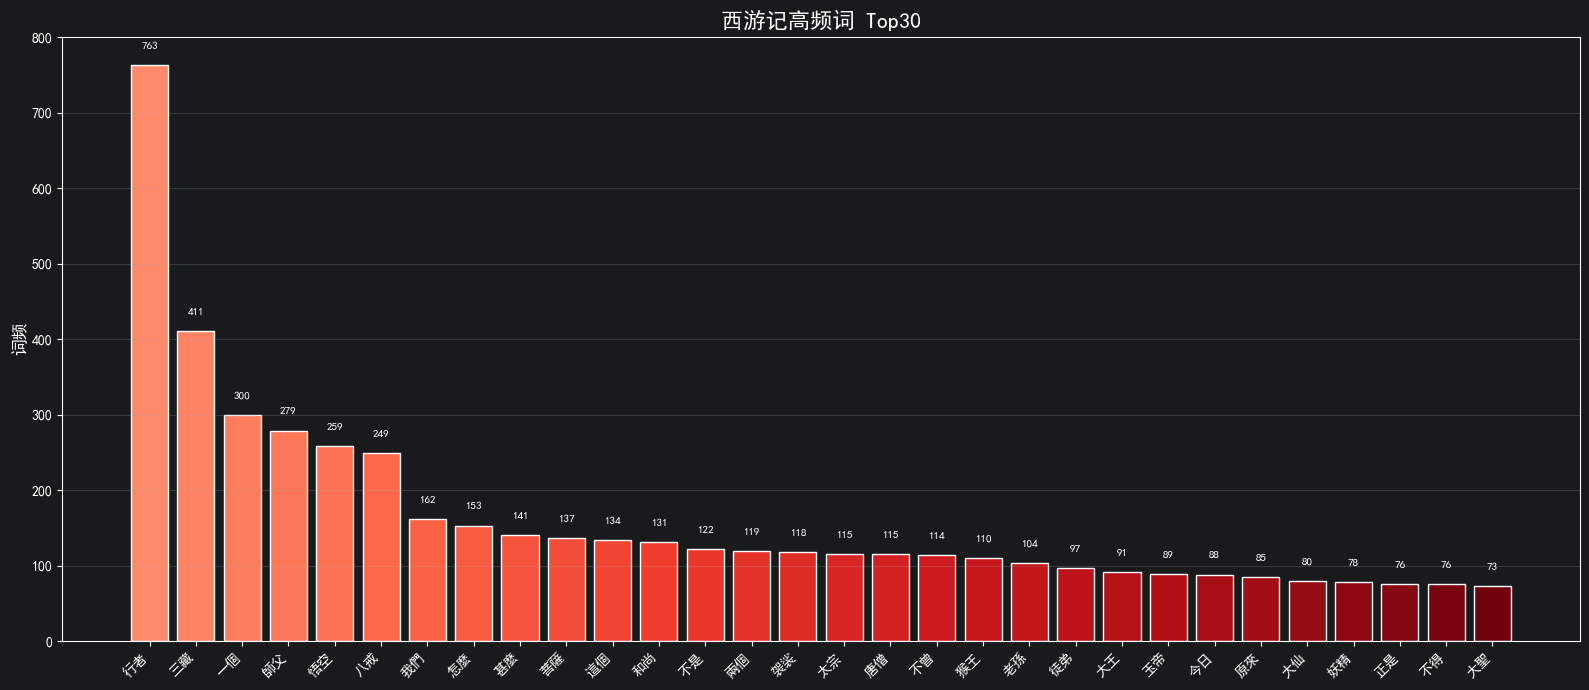


最高频词 "行者" 出现 763 次
前30词合计出现 4,869 次


In [99]:
# 4.2 高频词柱状图 (Top30)
if filtered_words:
    top30 = word_counter.most_common(30)
    words_30, freqs_30 = zip(*top30)

    fig, ax = plt.subplots(figsize=(16, 7))
    n = len(words_30)
    colors = plt.cm.Reds([(i / n) * 0.6 + 0.4 for i in range(n)])
    bars = ax.bar(range(n), freqs_30, color=colors, edgecolor='white')

    ax.set_xticks(range(n))
    ax.set_xticklabels(words_30, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('词频', fontsize=12)
    ax.set_title('西游记高频词 Top30', fontsize=16, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    for bar, freq in zip(bars, freqs_30):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(freq), ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig('word_frequency_top30.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\n最高频词 "{words_30[0]}" 出现 {freqs_30[0]} 次')
    print(f'前30词合计出现 {sum(freqs_30):,} 次')

## 5. 词云图绘制

使用 `wordcloud` 库生成词云图，直观展示《西游记》的核心词汇分布。

- 词云中词语大小反映其出现频率
- 使用与小说主题相关的色彩方案
- 自动检测系统可用的中文字体

In [100]:
# 5.1 自动检测中文字体路径
import matplotlib.font_manager as fm

def get_chinese_font_path():
    for path in [
        'C:/Windows/Fonts/simhei.ttf',
        'C:/Windows/Fonts/msyh.ttc',
        'C:/Windows/Fonts/simsun.ttc',
        'C:/Windows/Fonts/simkai.ttf',
    ]:
        if os.path.exists(path):
            return path
    for font in fm.fontManager.ttflist:
        if any(kw in font.name.lower() for kw in ['sim', 'hei', 'kai', 'yahei']):
            return font.fname
    return None

font_path = get_chinese_font_path()
if font_path:
    print(f'使用字体: {font_path}')
else:
    print('警告：未找到中文字体！请确保 C:/Windows/Fonts/simhei.ttf 存在。')

使用字体: C:/Windows/Fonts/simhei.ttf


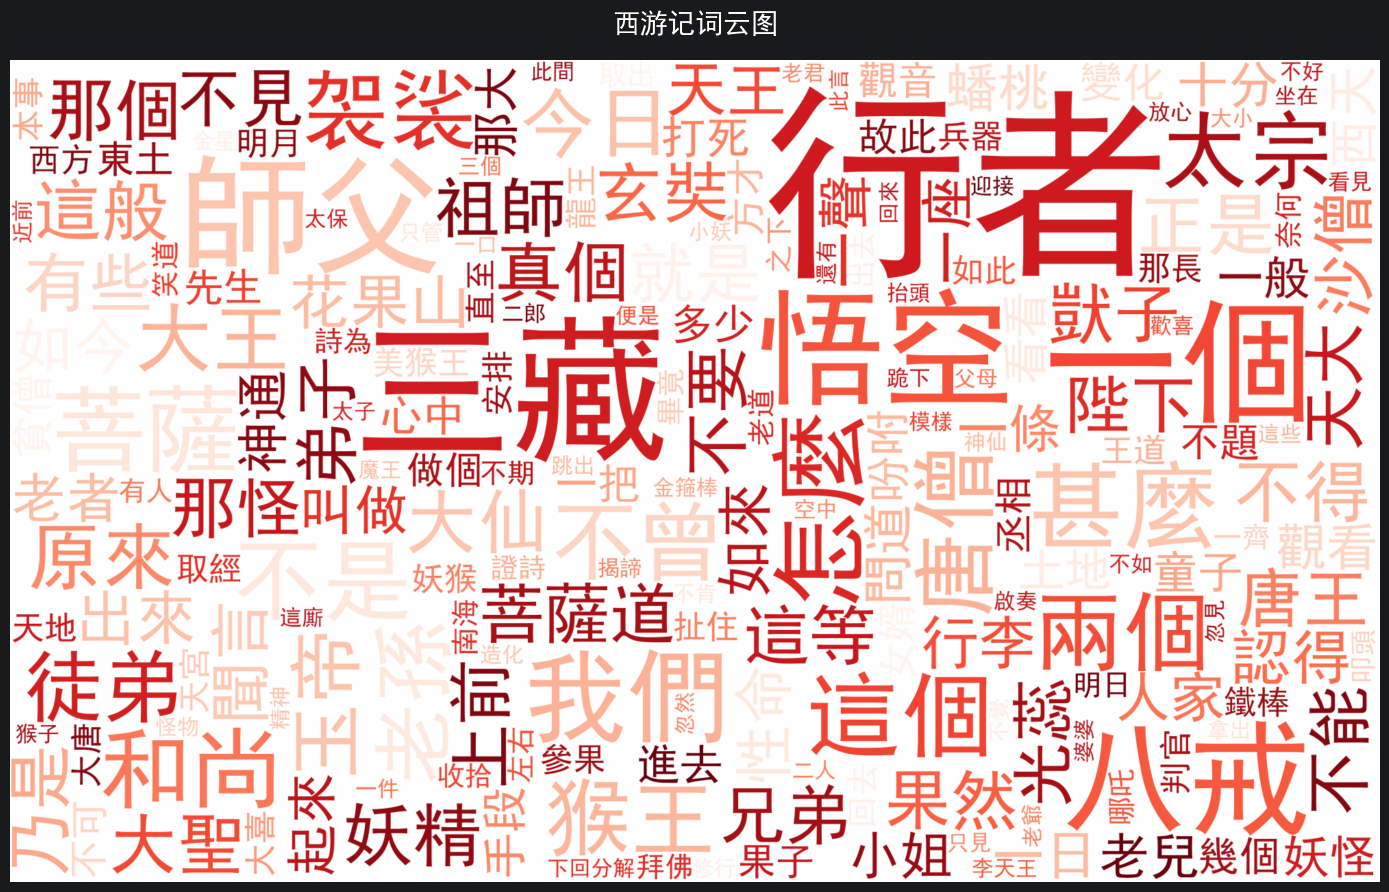

词云图已生成并保存为 xiyouji_wordcloud.png


In [101]:
# 5.2 生成词云主图
if filtered_words and font_path:
    wordcloud_text = ' '.join(filtered_words)

    wc = WordCloud(
        font_path=font_path,
        width=1000, height=600,
        background_color='white',
        max_words=200,
        max_font_size=150,
        min_font_size=8,
        collocations=False,
        prefer_horizontal=0.85,
        colormap='Reds',
        contour_color='firebrick',
        contour_width=1,
        random_state=42,
        scale=2,
    )
    wc.generate(wordcloud_text)

    fig, ax = plt.subplots(figsize=(14, 9))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('西游记词云图', fontsize=20, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('xiyouji_wordcloud.png', dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print('词云图已生成并保存为 xiyouji_wordcloud.png')
else:
    print('无法生成词云：数据或字体缺失。')

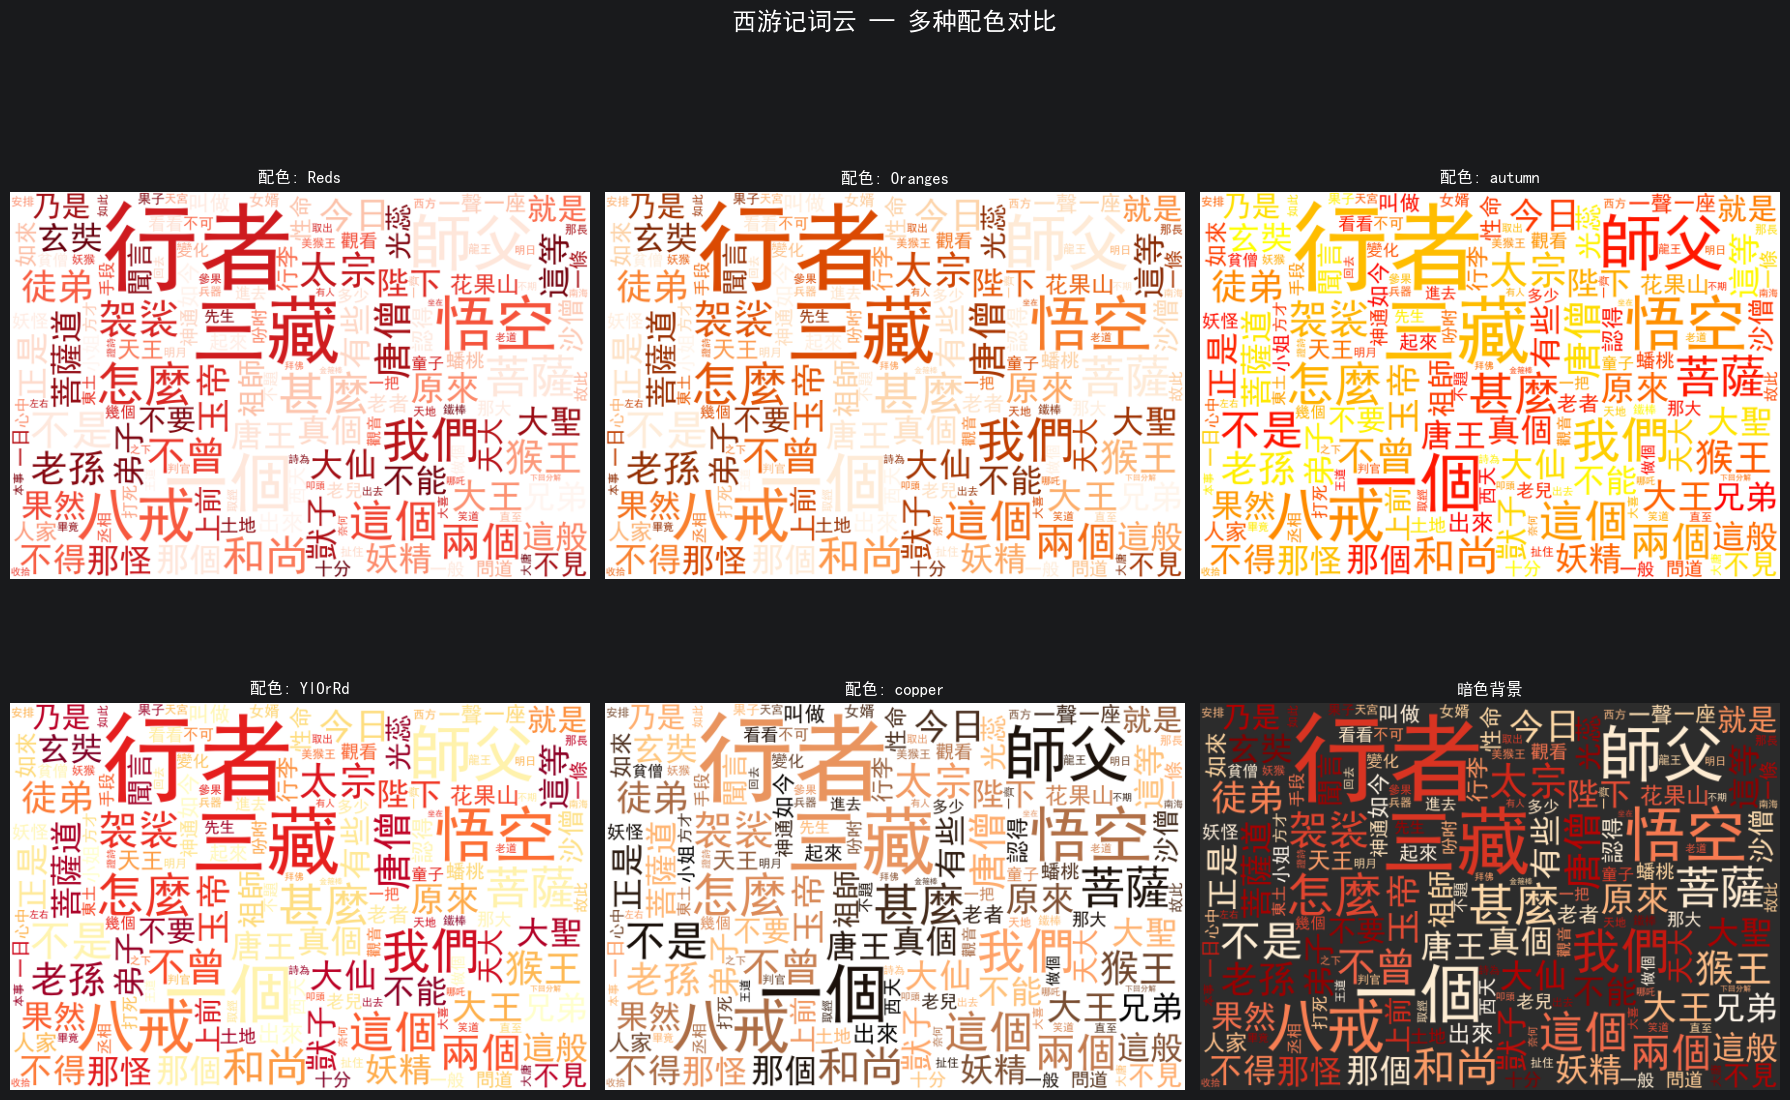

In [102]:
# 5.3 多种配色方案的词云变体
if filtered_words and font_path:
    wordcloud_text = ' '.join(filtered_words)
    color_maps = ['Reds', 'Oranges', 'autumn', 'YlOrRd', 'copper']

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, cmap in enumerate(color_maps):
        wc = WordCloud(font_path=font_path, width=600, height=400,
                       background_color='white', max_words=150,
                       max_font_size=100, min_font_size=6,
                       collocations=False, colormap=cmap, random_state=42)
        wc.generate(wordcloud_text)
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].axis('off')
        axes[i].set_title(f'配色: {cmap}', fontsize=12)

    wc_dark = WordCloud(font_path=font_path, width=600, height=400,
                        background_color='#2C2C2C', max_words=150,
                        max_font_size=100, min_font_size=6,
                        collocations=False, colormap='OrRd', random_state=42)
    wc_dark.generate(wordcloud_text)
    axes[5].imshow(wc_dark, interpolation='bilinear')
    axes[5].axis('off')
    axes[5].set_title('暗色背景', fontsize=12, color='white')
    axes[5].set_facecolor('#2C2C2C')

    plt.suptitle('西游记词云 — 多种配色对比', fontsize=18, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('xiyouji_wordcloud_variants.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. 数据分析与讨论

In [103]:
# 6.1 词频分布统计
if filtered_words:
    freqs = [freq for _, freq in word_counter.most_common()]
    print('===== 词频分布统计 =====')
    print(f'总词数 (去重后): {len(word_counter):,}')
    print(f'总词数 (含重复): {len(filtered_words):,}')
    print(f'最高频词出现次数: {freqs[0]}')
    print(f'仅出现1次的词数: {sum(1 for f in freqs if f == 1):,}')
    print(f'出现 >= 100次的词数: {sum(1 for f in freqs if f >= 100)}')
    print(f'出现 >= 50次的词数: {sum(1 for f in freqs if f >= 50)}')

    total = sum(freqs)
    print(f'\n===== 高频词累计覆盖率 =====')
    for t in [10, 20, 50, 100, 200, 500]:
        coverage = sum(freqs[:t]) / total * 100
        print(f'前{t:3d}个词覆盖了总词数的 {coverage:.1f}%')

===== 词频分布统计 =====
总词数 (去重后): 22,916
总词数 (含重复): 51,083
最高频词出现次数: 763
仅出现1次的词数: 16,892
出现 >= 100次的词数: 20
出现 >= 50次的词数: 57

===== 高频词累计覆盖率 =====
前 10个词覆盖了总词数的 5.6%
前 20个词覆盖了总词数的 7.9%
前 50个词覆盖了总词数的 12.0%
前100个词覆盖了总词数的 16.1%
前200个词覆盖了总词数的 21.5%
前500个词覆盖了总词数的 30.4%


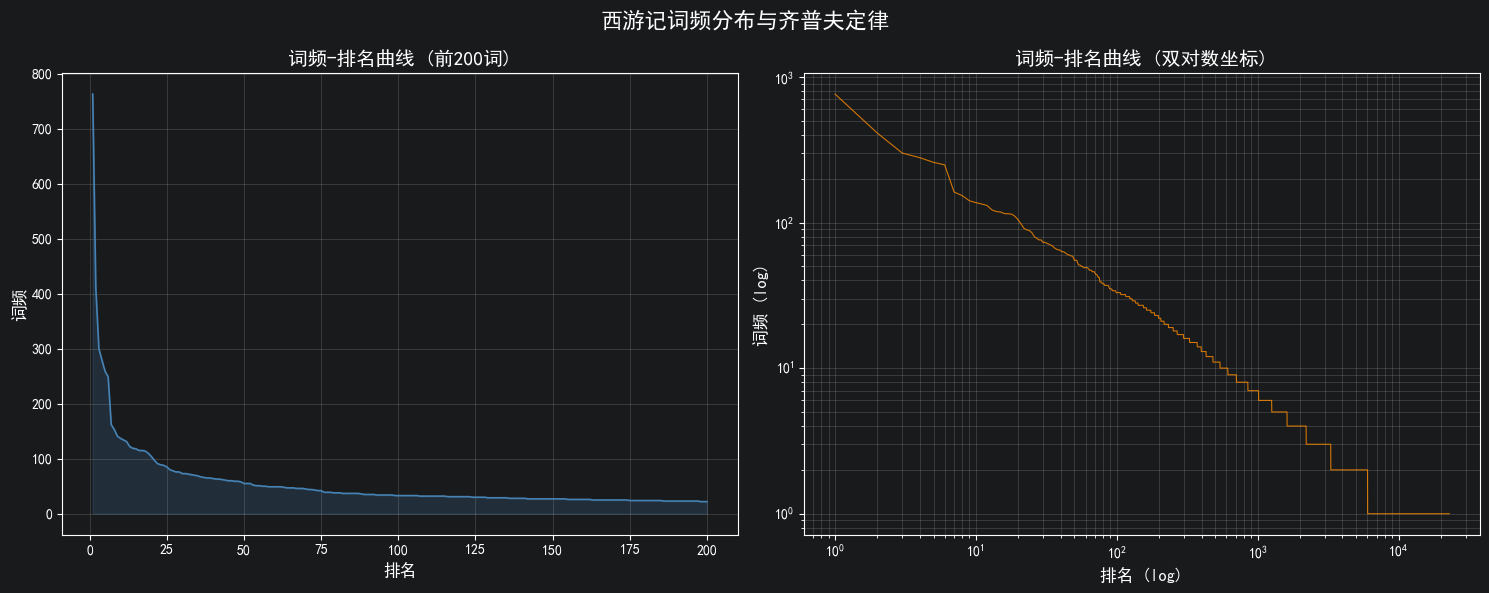

Zipf's Law: 在自然语言语料中，词的出现频率与其排名成反比。
双对数图若近似为直线，则说明《西游记》文本基本符合齐普夫定律。


In [104]:
# 6.2 词频分布曲线（齐普夫定律验证）
if filtered_words:
    freqs = [freq for _, freq in word_counter.most_common()]
    ranks = list(range(1, len(freqs) + 1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    ax1.plot(ranks[:200], freqs[:200], linewidth=1.2, color='steelblue')
    ax1.fill_between(ranks[:200], freqs[:200], alpha=0.2, color='steelblue')
    ax1.set_xlabel('排名', fontsize=12)
    ax1.set_ylabel('词频', fontsize=12)
    ax1.set_title('词频-排名曲线 (前200词)', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    ax2.loglog(ranks, freqs, linewidth=0.8, color='darkorange', alpha=0.8)
    ax2.set_xlabel('排名 (log)', fontsize=12)
    ax2.set_ylabel('词频 (log)', fontsize=12)
    ax2.set_title('词频-排名曲线 (双对数坐标)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, which='both')

    plt.suptitle('西游记词频分布与齐普夫定律', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('zipf_law.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Zipf's Law: 在自然语言语料中，词的出现频率与其排名成反比。")
    print('双对数图若近似为直线，则说明《西游记》文本基本符合齐普夫定律。')

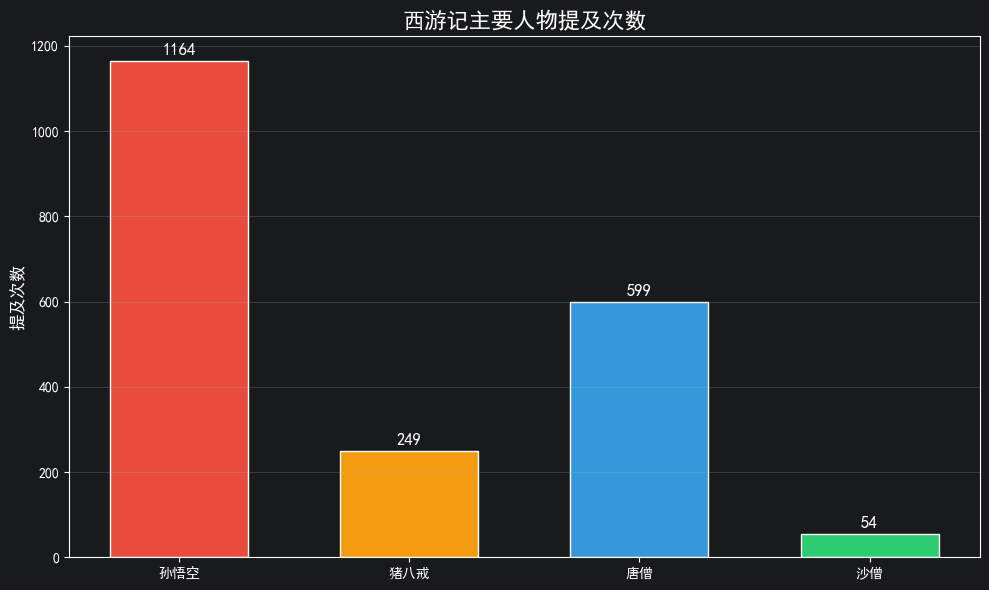

===== 西游记主要人物提及次数 =====
  孙悟空: 1164 次
  猪八戒: 249 次
  唐僧: 599 次
  沙僧: 54 次

  孙悟空称呼细分: 悟空=259 行者=763 猴王=110 


In [105]:
# 6.3 《西游记》主要人物词频分析
if filtered_words:
    swk_total = sum(word_counter.get(name, 0) for name in
                    ['悟空', '行者', '孙悟空', '大圣', '猴王', '美猴王', '齐天大圣'])
    zbj_total = sum(word_counter.get(name, 0) for name in
                    ['八戒', '悟能', '猪八戒', '呆子'])
    ssl_total = sum(word_counter.get(name, 0) for name in
                    ['沙僧', '悟净', '沙和尚'])
    ts_total = sum(word_counter.get(name, 0) for name in
                    ['唐僧', '三藏', '玄奘', '师父'])

    fig, ax = plt.subplots(figsize=(10, 6))
    people = ['孙悟空', '猪八戒', '唐僧', '沙僧']
    counts = [swk_total, zbj_total, ts_total, ssl_total]
    colors_bar = ['#E74C3C', '#F39C12', '#3498DB', '#2ECC71']

    bars = ax.bar(people, counts, color=colors_bar, edgecolor='white', width=0.6)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.set_ylabel('提及次数', fontsize=12)
    ax.set_title('西游记主要人物提及次数', fontsize=16, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('character_freq.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('===== 西游记主要人物提及次数 =====')
    for name, count in zip(people, counts):
        print(f'  {name}: {count} 次')
    print(f'\n  孙悟空称呼细分: ', end='')
    for name in ['悟空', '行者', '孙悟空', '大圣', '猴王']:
        if name in word_counter:
            print(f'{name}={word_counter[name]} ', end='')
    print()

## 7. 总结

### 7.1 实验流程回顾

| 步骤 | 内容 | 工具/方法 |
|------|------|-----------|
| **下载** | 从 Gutenberg 多段重试获取全文 | requests + Range 请求头 |
| **爬虫演示** | 爬取 Gutenberg 书目页获取元数据 | requests + BeautifulSoup |
| **清洗** | 去除英文、数字、标点等非中文字符 | 正则表达式 re |
| **分词** | 将清洗后文本切分为词语序列 | jieba 精确模式 |
| **过滤** | 去除停用词和单字词 | 自定义停用词表 |
| **统计** | 统计词频、分析分布规律 | collections.Counter |
| **可视化** | 绘制词云图、柱状图 | wordcloud + matplotlib |

### 7.2 教材知识点对应

本实验覆盖了《Python中文自然语言处理》第二章「文本预处理」的核心知识点：

1. **爬虫** — 使用 requests + BeautifulSoup 获取在线语料
2. **分词** — 使用 jieba 精确模式对中文文本进行分词（教材 2.1节）
3. **停用词过滤** — 去除无效高频虚词，提升分析质量
4. **文本清洗** — 正则表达式去除噪音数据

### 7.3 爬虫技术要点

- **多段重试策略**：利用 HTTP Range 请求头分段下载，单段失败不影响其他段
- **请求头伪装**：设置 User-Agent 模拟浏览器访问
- **本地缓存**：下载成功后保存本地，下次直接读取

### 7.4 改进方向

1. 引入更完整的中文停用词表（如哈工大停用词表、百度停用词表）
2. 使用 jieba 自定义词典，提高人名、地名等专有名词的分词准确率
3. 尝试生成指定形状的词云（如猴子形状）
4. 对不同章节进行对比分析，观察人物重要度随情节的变化